In [10]:
%matplotlib inline

import torch
import torch.nn as nn

Matplotlib is building the font cache; this may take a moment.


In [2]:
class DummyGPTModel(nn.Module):

    def __init__(self, cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"], cfg['emb_dim'])
        self.pos_emb=nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb=nn.Dropout(cfg['drop_rate'])
        self.trf_blocks=nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )
        self.final_norm=DummyLayerNorm(cfg['emb_dim'])
        self.out_head=nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)

    def forward(self, in_idx, verbose=False):
        batch_size, seq_len=in_idx.shape
        tok_embeds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        if verbose: print(f"{tok_embeds.shape=}, {pos_embeds.shape=}")
        x=tok_embeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        if verbose: print(f"{x.shape=}, {logits.shape=}")
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg): super().__init__()
    def forward(self, x): return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5): super().__init__()
    def forward(self, x): return x
    

In [3]:
# configuration of the small GPT-2
GPT_CONFIG_124M={
    "vocab_size":50257,       # Vocabulary size
    "context_length":1024,    # Context length
    "emb_dim":768,            # Embedding dimension
    "n_heads":12,             # Number of attention heads
    "n_layers":12,            # Number of layers
    "drop_rate":0.1,          # Dropout rate
    "qkv_bias": False         # Query-key-value bias
}

In [4]:
import tiktoken

tokenizer=tiktoken.get_encoding('gpt2')
txt1="Every effort moves you"
txt2="Every day holds a"

batch=[torch.tensor(tokenizer.encode(txt1))]
batch+=[torch.tensor(tokenizer.encode(txt2))]
print(f"{[x.shape for x in batch]=}")
batch=torch.stack(batch, dim=0)
print(f"{batch.shape=}\n{batch}")

[x.shape for x in batch]=[torch.Size([4]), torch.Size([4])]
batch.shape=torch.Size([2, 4])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch, verbose=True)
print(f"Output shape: {logits.shape=}")
print(f"{logits=}")

tok_embeds.shape=torch.Size([2, 4, 768]), pos_embeds.shape=torch.Size([4, 768])
x.shape=torch.Size([2, 4, 768]), logits.shape=torch.Size([2, 4, 50257])
Output shape: logits.shape=torch.Size([2, 4, 50257])
logits=tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0448,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


In [6]:
torch.manual_seed(123)
batch_example=torch.rand(2,5)
layer=nn.Sequential(nn.Linear(5,6), nn.ReLU())
out=layer(batch_example)
print(f"{out.shape=}\n{out}")
mean=out.mean(dim=-1, keepdim=True)
var=out.var(dim=-1, keepdim=True)
print(f"{mean=}")
print(f"{var=}")

out_norm=(out-mean)/var.sqrt()
mean=out_norm.mean(dim=-1, keepdim=True)
var=out_norm.var(dim=-1, keepdim=True)
print(f"normalized layer output {out_norm=}")
print(f"{mean=}\n{var=}")

out.shape=torch.Size([2, 6])
tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)
mean=tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)
var=tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)
normalized layer output out_norm=tensor([[-0.8603, -0.8603,  0.5869,  1.4698,  0.5242, -0.8603],
        [-0.7450, -0.7450, -0.0102,  0.4844,  1.7608, -0.7450]],
       grad_fn=<DivBackward0>)
mean=tensor([[ 0.0000e+00],
        [-4.4703e-08]], grad_fn=<MeanBackward1>)
var=tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [7]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        """
        Operate on the last dimension of input tensor
        """
        super().__init__()
        self.eps=1e-5
        # trainable parameters that the model automatically adjusts during training if it is determined that doing so would
        # improve the model's performance
        self.scale=nn.Parameter(torch.ones(emb_dim))
        self.shift=nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean=x.mean(dim=-1, keepdim=True)
        var=x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x=(x-mean)/(var+self.eps).sqrt()
        return self.scale*norm_x+self.shift

ln=LayerNorm(emb_dim=6)
out_ln=ln(out)
print(f"{out.shape=}\n{out}")
print(f"{out_ln.shape=}\n{out_ln}")
mean=out_ln.mean(dim=-1, keepdim=True)
var=out_ln.var(dim=-1, unbiased=False, keepdim=True)
print(f"{mean=}\n{var=}")

out.shape=torch.Size([2, 6])
tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)
out_ln.shape=torch.Size([2, 6])
tensor([[-0.9423, -0.9423,  0.6428,  1.6100,  0.5742, -0.9423],
        [-0.8160, -0.8160, -0.0111,  0.5306,  1.9286, -0.8160]],
       grad_fn=<AddBackward0>)
mean=tensor([[ 5.9605e-08],
        [-4.9671e-08]], grad_fn=<MeanBackward1>)
var=tensor([[0.9998],
        [0.9998]], grad_fn=<VarBackward0>)


In [14]:
class GELU(nn.Module):

    def __init__(self): super().__init__()
    def forward(self, x):
        return 0.5 * x * (1.+torch.tanh(
                                     torch.sqrt(torch.tensor(2./torch.pi)) * 
                                     (x + 0.044715 * torch.pow(x, 3.))
                                   )
                     )

torch.min(x).item()=-3.0, torch.max(x).item()=3.0
torch.min(x).item()=-3.0, torch.max(x).item()=3.0


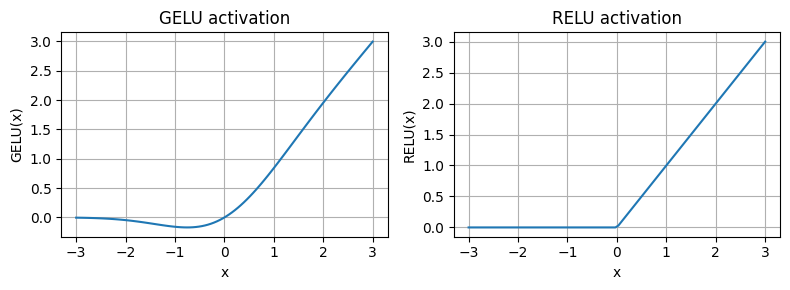

In [15]:
import matplotlib.pyplot as plt

gelu, relu=GELU(), nn.ReLU()

x=torch.linspace(-3,3,100)
y_gelu, y_relu=gelu(x), relu(x)
fig, axes=plt.subplots(1,2,figsize=(8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu],["GELU", "RELU"])):
    print(f"{torch.min(x).item()=}, {torch.max(x).item()=}")
    axes[i].plot(x, y)
    axes[i].set_title(f"{label} activation")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"{label}(x)")
    axes[i].grid(True)
plt.tight_layout()

In [17]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4*cfg['emb_dim']),
            GELU(),
            nn.Linear(4*cfg['emb_dim'], cfg['emb_dim'])
        )

    def forward(self, x): return self.layers(x)

ffn=FeedForward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out=ffn(x)
print(f"{out.shape=}, {out.dtype=}")

out.shape=torch.Size([2, 3, 768]), out.dtype=torch.float32


In [19]:
class ExampleDeepNeuralNetwork(nn.Module):

    def __init__(self, layer_sizes, use_shortcut):
        assert len(layer_sizes)==6
        
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[l], layer_sizes[l+1]), GELU()) for l in range(5)
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output=layer(x)
            if self.use_shortcut and x.shape==layer_output.shape: # check if shortcut can be applied
                x=x+layer_output
            else: x=layer_output
        return x

def print_gradients(model, x):
    """
    Computes the gradients in the model's backward pass
    """
    output=model(x) # forward pass
    target=torch.tensor([[0.]])

    loss=nn.MSELoss()(output, target) # calculate loss based on how close the target and output is

    loss.backward() # backward pass to calculate gradients

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")
    
    

layer_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(layer_sizes=layer_sizes, use_shortcut=False)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


In [20]:
torch.manual_seed(123)
model_with_shortcut=ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472
